In [1]:

import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import keras
from keras import layers
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================================================
# 1. Carregamento e Pré-processamento dos Dados
# =========================================================
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/PROJETOS_IA_CV/CIC/'

parquet_files = [
    'Benign-Monday-no-metadata.parquet',
    'Botnet-Friday-no-metadata.parquet',
    'Bruteforce-Tuesday-no-metadata.parquet',
    'DDoS-Friday-no-metadata.parquet',
    'DoS-Wednesday-no-metadata.parquet',
    'Infiltration-Thursday-no-metadata.parquet',
    'Portscan-Friday-no-metadata.parquet',
    'WebAttacks-Thursday-no-metadata.parquet',
]

df_list = [
    pd.read_parquet(os.path.join(base_path, f))
    for f in parquet_files
    if os.path.exists(os.path.join(base_path, f))
]
df = pd.concat(df_list, ignore_index=True).drop_duplicates()

df.columns = df.columns.str.strip()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Rótulo y: 0 para Benign, 1 para Ataque
y = df['Label'].apply(lambda x: 0 if str(x).strip().lower() == 'benign' else 1)
X = df.drop(columns=['Label']).apply(pd.to_numeric, errors='coerce').dropna()
y = y.loc[X.index]
X = X.loc[:, X.std() > 0]



Mounted at /content/drive


In [2]:
# 2. Divisão de Dados Supervisionada (Treino com AMBOS os rótulos)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
 # 3. Arquitetura da Rede Neural Classificadora (DNN)

input_dim = X_train_scaled.shape[1]

classifier = keras.Sequential(
    [
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid'),  # Saída Binária (0 a 1)
    ],
    name='dnn_classifier',
)

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
)

classifier.summary()


Model: "dnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,329 (75.50 KB)

 Trainable params: 19,329 (75.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 4. Treinamento
# =========================================================
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

history = classifier.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=1024,
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=True,
    verbose=1,
)

Epoch 1/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9803 - auc: 0.9927 - loss: 0.0613 - val_accuracy: 0.9877 - val_auc: 0.9977 - val_loss: 0.0368 - learning_rate: 0.0010
Epoch 2/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9871 - auc: 0.9971 - loss: 0.0365 - val_accuracy: 0.9892 - val_auc: 0.9982 - val_loss: 0.0290 - learning_rate: 0.0010
Epoch 3/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9882 - auc: 0.9977 - loss: 0.0317 - val_accuracy: 0.9887 - val_auc: 0.9987 - val_loss: 0.0275 - learning_rate: 0.0010
Epoch 4/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9889 - auc: 0.9980 - loss: 0.0293 - val_accuracy: 0.9912 - val_auc: 0.9990 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 5/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9894 - auc: 0.9982 - loss: 0.0279 - val_accuracy: 0.9888 - val_auc: 0.9983 - val_loss: 0.0298 - learning_rate: 0.0010
Epoch 6/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy

In [7]:
# 5. Avaliação e Métricas
# Predição de probabilidades
y_pred_prob = classifier.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)  # Limite padrão de decisão 0.5

print('\n--- Matriz de Confusão (DNN Supervisionada) ---')
print(confusion_matrix(y_test, y_pred))

print('\n--- Relatório de Classificação ---')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Ataque']))


13949/13949 ━━━━━━━━━━━━━━━━━━━━ 13s 898us/step

--- Matriz de Confusão (DNN Supervisionada) ---
[[378200    863]
 [  1531  65768]]

--- Relatório de Classificação ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    379063
      Ataque       0.99      0.98      0.98     67299

    accuracy                           0.99    446362
   macro avg       0.99      0.99      0.99    446362
weighted avg       0.99      0.99      0.99    446362



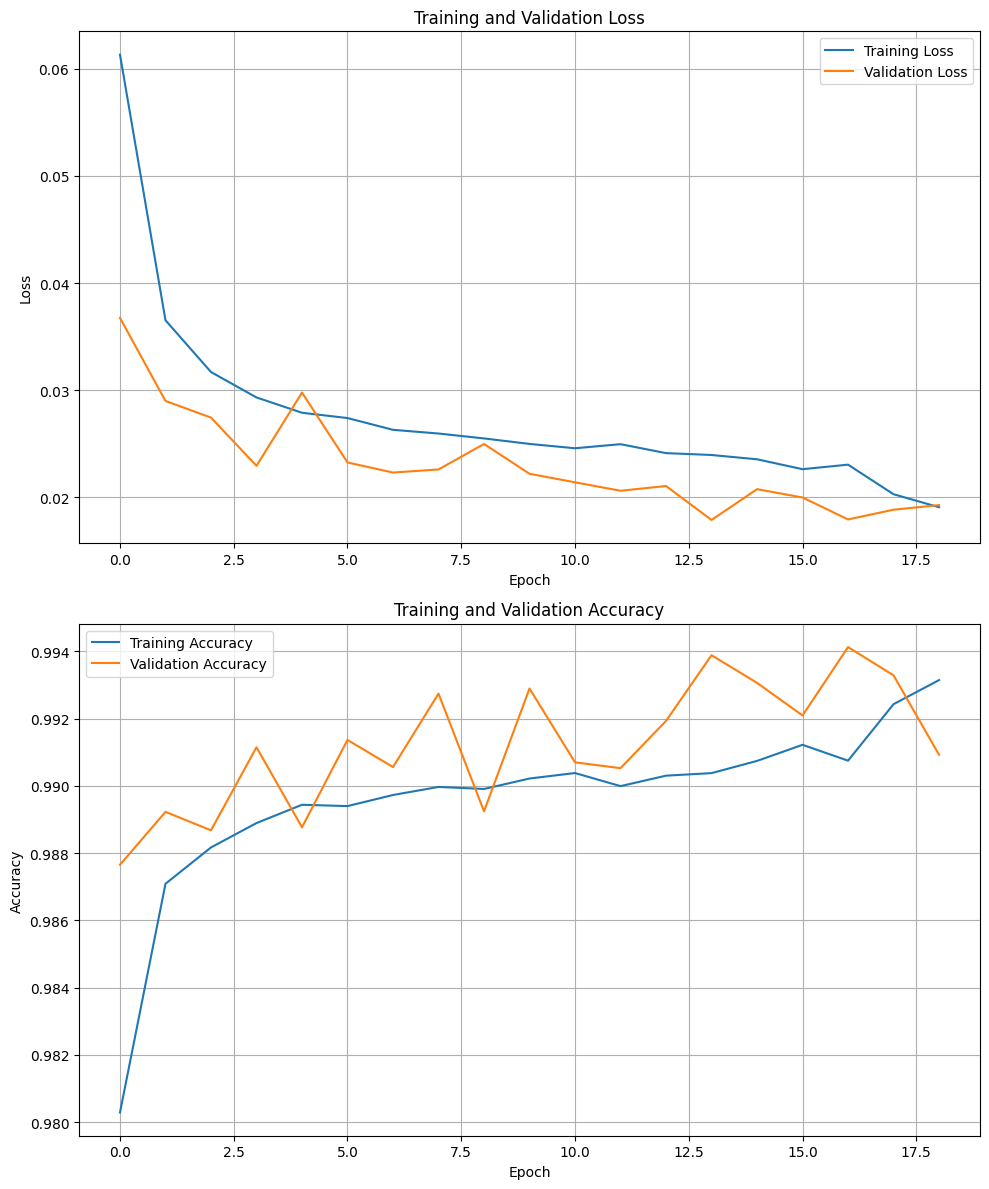

In [10]:
import seaborn as sns

train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

# Create a figure and axes for subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))

# Plot loss curves
sns.lineplot(x=range(len(train_loss)), y=train_loss, ax=axes[0], label='Training Loss')
sns.lineplot(x=range(len(val_loss)),   y=val_loss, ax=axes[0], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Plot accuracy curves
sns.lineplot(x=range(len(train_acc)), y=train_acc, ax=axes[1], label='Training Accuracy')
sns.lineplot(x=range(len(val_acc)),   y=val_acc, ax=axes[1], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
